In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import make_scorer, matthews_corrcoef, f1_score, balanced_accuracy_score, precision_score, recall_score,  precision_recall_curve, average_precision_score, roc_curve, auc

In [2]:
# 1. Load data
df = pd.read_csv('ppi.csv')

In [ ]:
# 2. Splitting 
unique_proteins = df['uniprot_id'].unique()
train_val_ids, test_ids = train_test_split(unique_proteins, test_size=0.20, random_state=22)
train_ids, val_ids = train_test_split(train_val_ids, test_size=0.25, random_state=23)
train_data = df[df['uniprot_id'].isin(train_ids)]

In [ ]:
# 3. MODELS WITH RLENGTH AND NORMALIZED LENGTH
metadata = ['Unnamed: 0', 'domain', 'aa_ProtPosition', 'uniprot_id', 'sequence', 'p_interface'] # Removed length from here

# Global features to be included in every model
global_features = ['Rlength', 'normalized_length']

# Base + Global
base_features = global_features + [
    'normalized_abs_surf_acc', 'normalized_hydropathy_index', 'rel_surf_acc',
    'prob_sheet', 'prob_helix', 'prob_coil'
] + [c for c in df.columns if c.startswith('pssm_') and '_wm_' not in c]

feature_sets = {
    "Model 1: Base + Length": base_features,
    "Model 2: Window 3 + Length": global_features + [c for c in df.columns if c.startswith('3_wm_')],
    "Model 3: Window 5 + Length": global_features + [c for c in df.columns if c.startswith('5_wm_')],
    "Model 4: Window 7 + Length": global_features + [c for c in df.columns if c.startswith('7_wm_')],
    "Model 5: Window 9 + Length": global_features + [c for c in df.columns if c.startswith('9_wm_')]
}

In [ ]:
# 4. Imbalance Configurations 
ros = RandomOverSampler(random_state=44)
rus = RandomUnderSampler(random_state=33)
y_train = train_data['p_interface']
xgb_ratio = float(y_train.value_counts()[0] / y_train.value_counts()[1])

configs = [
    ("RF (Undersampled)", Pipeline([
        ('resampler', rus), 
        ('model', RandomForestClassifier(
            n_estimators=400,           
            max_depth=None,           
            max_features='sqrt',        
            min_samples_split=2,        
            random_state=66, 
            n_jobs=-1
        ))
    ])),
    
    ("XGBoost (Class Weight)", XGBClassifier(
        scale_pos_weight=xgb_ratio, 
        learning_rate=0.01,            
        n_estimators=500,               
        max_depth=10,                  
        subsample=0.8,                  
        colsample_bytree=0.8,           
        eval_metric='logloss', 
        random_state=100
    ))
]

In [7]:
# 5. Metrics & CV
scoring = {
    'MCC': make_scorer(matthews_corrcoef),
    'F1': make_scorer(f1_score, zero_division=0),
    'ROC-AUC': 'roc_auc',
    'Bal.Acc': make_scorer(balanced_accuracy_score),
    'Precision': make_scorer(precision_score, pos_label=1, zero_division=0),
    'Recall': make_scorer(recall_score, zero_division=0)
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
output_dir = 'model_outputs'
os.makedirs(output_dir, exist_ok=True)

final_results = []

saved_files_registry = {} 

for model_name, features in feature_sets.items():
    print(f"Testing {model_name}...")
    X_train_sub = train_data[features]
    y_train = train_data['p_interface']
    
    for config_name, clf in configs:
        y_probas = cross_val_predict(clf, X_train_sub, y_train, cv=cv, method='predict_proba', n_jobs=-1)
        probs = y_probas[:, 1]
        
        safe_model = model_name.replace(" ", "_").replace(":", "").replace("+", "plus")
        safe_config = config_name.replace(" ", "_").replace("(", "").replace(")", "")
        filename = f"{safe_model}_{safe_config}.csv"
        file_path = os.path.join(output_dir, filename)
        
   
        pd.DataFrame({'y_true': y_train, 'y_prob': probs}).to_csv(file_path, index=False)
        
        if config_name not in saved_files_registry:
            saved_files_registry[config_name] = []
        saved_files_registry[config_name].append((model_name, file_path))
        
        scores = cross_validate(clf, X_train_sub, y_train, cv=cv, scoring=scoring, n_jobs=-1)
        final_results.append({
            'Model': model_name, 'Config': config_name,
            'MCC': np.mean(scores['test_MCC']).round(3),
            'F1': np.mean(scores['test_F1']).round(3),
            'AUC': np.mean(scores['test_ROC-AUC']).round(3),
            'Bal.Acc': np.mean(scores['test_Bal.Acc']).round(3),    
            'Precision': np.mean(scores['test_Precision']).round(3), 
            'Recall': np.mean(scores['test_Recall']).round(3)

        })

print("\n--- DONE: Files saved to model_outputs/ ---")

Testing Model 1: Base + Length...
Testing Model 2: Window 3 + Length...
Testing Model 3: Window 5 + Length...
Testing Model 4: Window 7 + Length...
Testing Model 5: Window 9 + Length...

--- DONE: Files saved to model_outputs/ ---


In [ ]:
# Summary table
results_df = pd.DataFrame(final_results)
print("\n--- FINAL CROSS-VALIDATION RESULTS ---")
print(results_df.to_string(index=False))


--- FINAL CROSS-VALIDATION RESULTS ---


                     Model                 Config   MCC    F1   AUC  Bal.Acc  Precision  Recall
    Model 1: Base + Length      RF (Undersampled) 0.235 0.329 0.741    0.676      0.217   0.679
    Model 1: Base + Length XGBoost (Class Weight) 0.288 0.382 0.777    0.675      0.311   0.495
Model 2: Window 3 + Length      RF (Undersampled) 0.275 0.355 0.774    0.705      0.235   0.725
Model 2: Window 3 + Length XGBoost (Class Weight) 0.315 0.404 0.806    0.681      0.346   0.485
Model 3: Window 5 + Length      RF (Undersampled) 0.314 0.384 0.809    0.731      0.259   0.750
Model 3: Window 5 + Length XGBoost (Class Weight) 0.360 0.442 0.832    0.711      0.371   0.546
Model 4: Window 7 + Length      RF (Undersampled) 0.347 0.408 0.831    0.754      0.276   0.782
Model 4: Window 7 + Length XGBoost (Class Weight) 0.388 0.464 0.847    0.736      0.376   0.607
Model 5: Window 9 + Length      RF (Undersampled) 0.375 0.428 0.851    0.772      0.292   0.805
Model 5: Window 9 + Length XGBoost (Clas

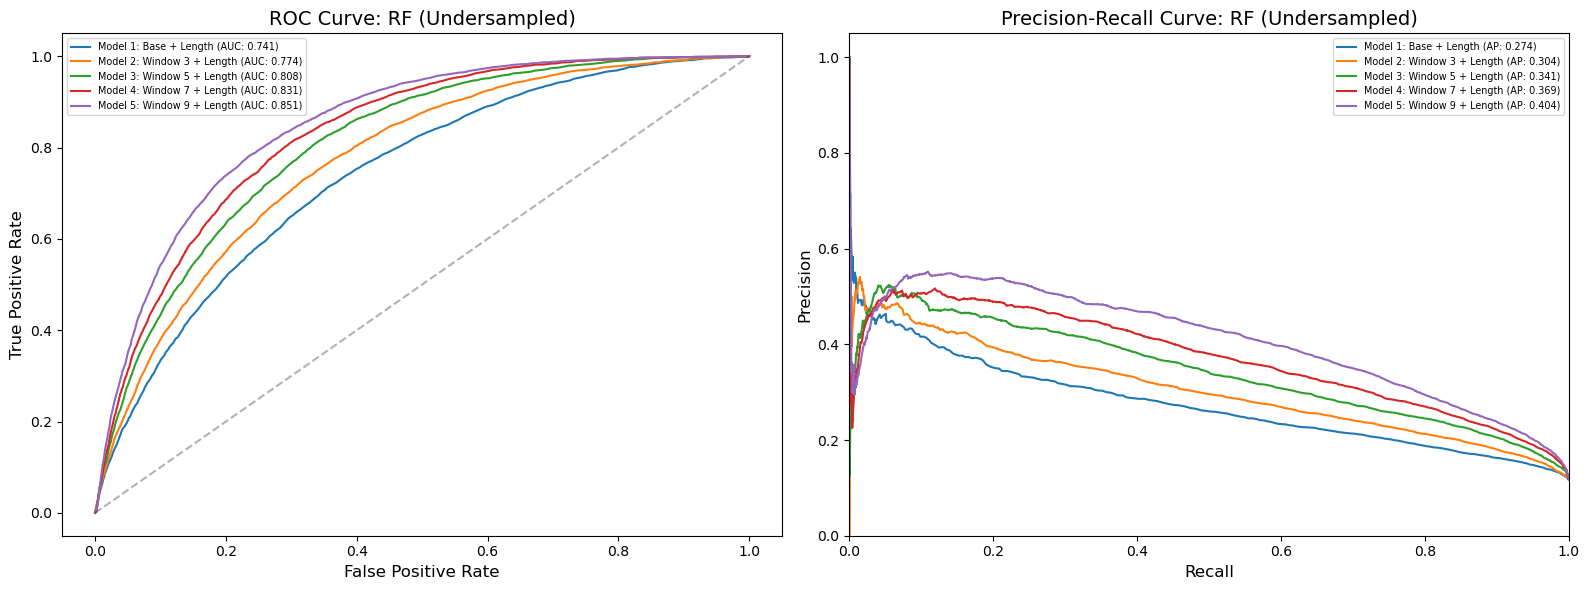

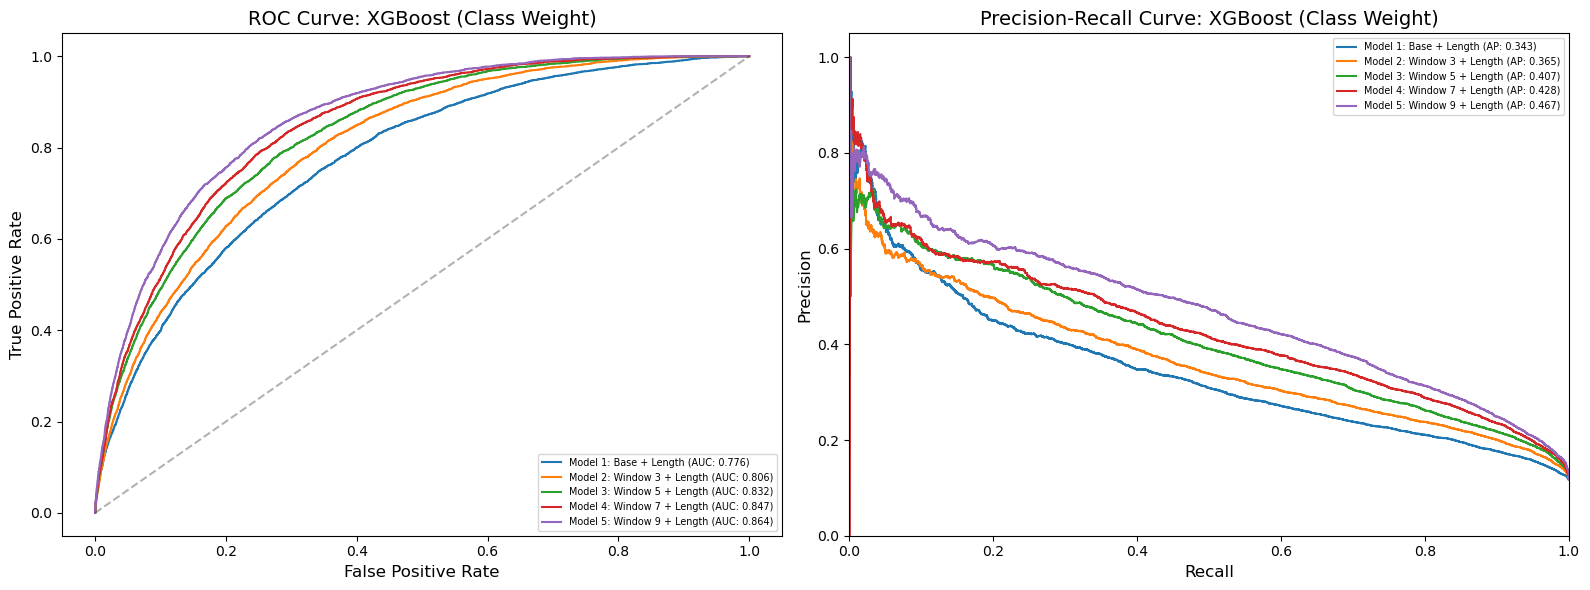

In [ ]:
# 6. Plotting ROC and PR Curves
for config_name, file_info_list in saved_files_registry.items():
    if config_name not in ["RF (Undersampled)", "XGBoost (Class Weight)"]:
        continue
        
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    for model_label, path in file_info_list:
        if not os.path.exists(path):
            continue
            
        data = pd.read_csv(path)
        y_true, y_prob = data['y_true'], data['y_prob']

        # 1. ROC Calculation
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        ax1.plot(fpr, tpr, label=f'{model_label} (AUC: {auc(fpr, tpr):.3f})')
        
        # 2. PR Calculation
        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        ax2.plot(recall, precision, label=f'{model_label} (AP: {average_precision_score(y_true, y_prob):.3f})')

    # ROC
    ax1.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax1.set_title(f'ROC Curve: {config_name}', fontsize=14)
    ax1.set_xlabel('False Positive Rate', fontsize=12) 
    ax1.set_ylabel('True Positive Rate', fontsize=12)  
    ax1.legend(fontsize='x-small')
    
    # PR
    ax2.set_title(f'Precision-Recall Curve: {config_name}', fontsize=14)
    ax2.set_xlabel('Recall', fontsize=12)            
    ax2.set_ylabel('Precision', fontsize=12)          
    ax2.set_xlim([0, 1.0])
    ax2.set_ylim([0, 1.05])
    ax2.legend(fontsize='x-small')
    
    plt.tight_layout()
    plt.show()